## Connect to Google Sheet

In [3]:
# Install necessary libraries
!pip install gspread gspread-dataframe

# Import libraries
import pandas as pd
import gspread
from google.colab import auth
from google.auth import default

Next, we need to authenticate Colab to access your Google Drive, where your Google Sheet is stored. When you run the cell below, a pop-up window will appear asking you to choose a Google account and grant permissions. Please follow the instructions.

In [5]:
# Authenticate with Google Drive
auth.authenticate_user()
gcreds, _ = default()
gc = gspread.Client(auth=gcreds)

Now, paste your Google Sheet URL into the `spreadsheet_url` variable. Then, we will open the sheet and load the specified 'clean_data' worksheet into a pandas DataFrame.

In [6]:
# YOUR GOOGLE SHEET URL GOES HERE
spreadsheet_url = "https://docs.google.com/spreadsheets/d/1kBWWAJlh3eLFaLfvQdjx-qtnijzl96RtNw65vRCtt4Q/edit?usp=sharing"

# Open the spreadsheet by URL
spreadsheet = gc.open_by_url(spreadsheet_url)

# Select the specific worksheet, as requested ('clean_data')
worksheet = spreadsheet.worksheet('Clean_Data')

# Get all values from the worksheet and convert to a pandas DataFrame
df = pd.DataFrame(worksheet.get_all_records())

# Display the first 5 rows of the DataFrame
display(df.head())

,Order_ID,Order_Date,Customer_ID,Customer_Type,Customer_Repeat,Product,Category,Region,Quantity,Revenue,Profit,Profit Category
0,1001,01/06/2026,C001,New Customer,1,Laptop,Electronics,Delhi,1,"₹65,000.00","₹8,000",Profit
1,1002,03/06/2026,C002,Repeat Customer,9,Phone,Electronics,Delhi,2,"₹50,000.00","₹6,000",Profit
2,1346,17/02/2026,C002,Repeat Customer,8,Jeans,Apparel,Mumbai,2,"₹5,984.00","₹2,078",Profit
3,1693,10/07/2026,C002,Repeat Customer,7,Table,Furniture,Mumbai,5,"₹59,945.00","₹13,995",Profit
4,1951,13/06/2026,C002,Repeat Customer,6,Shoes,Apparel,Chennai,1,"₹4,480.00","₹1,358",Profit


In [ ]:
df.tail()

,Order_ID,Order_Date,Customer_ID,Customer_Type,Customer_Repeat,Product,Category,Region,Quantity,Revenue,Profit,Profit Category
1995,2626,04/06/2026,GUEST,Repeat Customer,5,Headphones,Electronics,Mumbai,6,"₹37,398.00","₹7,803",Profit
1996,2752,11/07/2026,GUEST,Repeat Customer,4,Laptop,Electronics,Bangalore,1,"₹44,239.00","₹5,775",Profit
1997,2802,25/07/2026,GUEST,Repeat Customer,3,Cookware Set,Home,Pune,2,"₹9,868.00","₹2,091",Profit
1998,2918,01/02/2026,GUEST,Repeat Customer,2,Cookware Set,Home,Hyderabad,6,"₹13,314.00","₹2,835",Profit
1999,2945,08/06/2026,GUEST,Repeat Customer,1,Camera,Electronics,Chennai,6,"₹358,368.00","₹36,882",Profit


In [ ]:
df.sample(10)

,Order_ID,Order_Date,Customer_ID,Customer_Type,Customer_Repeat,Product,Category,Region,Quantity,Revenue,Profit,Profit Category
1728,1585,21/06/2026,C442,Repeat Customer,29,Kurta,Apparel,Mumbai,5,"₹8,695.00","₹2,393",Profit
1546,2087,12/05/2026,C396,Repeat Customer,7,Vacuum Cleaner,Home,Bangalore,6,₹0.00,"₹16,448",Profit
1968,2437,06/08/2026,C479,Repeat Customer,4,Cookware Set,Home,Bangalore,3,"₹18,678.00","₹4,114",Profit
885,1354,13/01/2026,C239,Repeat Customer,7,Perfume,Beauty,Pune,5,"₹29,560.00","₹9,635",Profit
332,1030,24/05/2026,C081,Repeat Customer,5,Chair,Furniture,Mumbai,1,"₹3,873.00",₹764,Profit
1863,1748,06/02/2026,C468,Repeat Customer,4,Shoes,Apparel,Mumbai,2,₹0.00,"₹2,413",Profit
686,1812,26/03/2026,C183,Repeat Customer,9,Jeans,Apparel,Mumbai,4,"₹5,068.00","₹1,499",Profit
1894,2069,24/03/2026,C473,Repeat Customer,3,Speaker,Electronics,Bangalore,1,"₹8,854.00","₹1,575",Profit
1511,1581,17/01/2026,C391,Repeat Customer,25,Vacuum Cleaner,Home,Hyderabad,1,"₹9,811.00","₹1,937",Profit
945,1879,21/03/2026,C248,Repeat Customer,11,Makeup Kit,Beauty,Hyderabad,4,"₹5,468.00","₹1,802",Profit


In [ ]:
df.shape

(2000, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         2000 non-null   int64         
 1   Order_Date       1977 non-null   datetime64[ns]
 2   Customer_ID      2000 non-null   object        
 3   Customer_Type    2000 non-null   object        
 4   Customer_Repeat  2000 non-null   int64         
 5   Product          2000 non-null   object        
 6   Category         2000 non-null   object        
 7   Region           2000 non-null   object        
 8   Quantity         2000 non-null   int64         
 9   Revenue          2000 non-null   object        
 10  Profit           2000 non-null   object        
 11  Profit Category  2000 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(8)
memory usage: 187.6+ KB


In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d/%m/%Y', errors='coerce')

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Order_ID,2000.0,1988.741,1001.0,1494.75,1988.5,2481.25,2977.0,570.083494
Order_Date,1977,2026-04-25 14:40:36.418816512,2026-01-01 00:00:00,2026-03-01 00:00:00,2026-04-24 00:00:00,2026-06-20 00:00:00,2026-08-20 00:00:00,NaN
Customer_Repeat,2000.0,6.127,1.0,2.0,4.0,8.0,45.0,6.85466
Quantity,2000.0,3.4335,0.0,2.0,3.0,5.0,6.0,1.766391


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,23
Customer_ID,0
Customer_Type,0
Customer_Repeat,0
Product,0
Category,0
Region,0
Quantity,0
Revenue,0


In [ ]:
# Option 1: Fill missing dates with the mean (as previously attempted)
# df['Order_Date'] = df['Order_Date'].fillna(df['Order_Date'].mean())

# Option 2: Fill missing dates using forward fill (propagates the last valid observation forward)
# This is useful if you assume the order date remained the same as the previous record.
df['Order_Date'] = df['Order_Date'].ffill()

# Option 3: Fill missing dates using backward fill (propagates the next valid observation backward)
# This is useful if you assume the order date was the same as the next record.
# df['Order_Date'] = df['Order_Date'].bfill()

# For Dropping missing

# df.dropna(subset=['Order_Date'], inplace=True)

In [ ]:
df.isnull().any()

,0
Order_ID,False
Order_Date,False
Customer_ID,False
Customer_Type,False
Customer_Repeat,False
Product,False
Category,False
Region,False
Quantity,False
Revenue,False


In [ ]:
print("1. Number of rows and columns:")
print(df.shape)

print("\n2. Column names:")
print(df.columns.tolist())

print("\n3. Data types and non-null counts:")
df.info()

print("\n4. Summary statistics:")
display(df.describe(include='all'))

print("\n5. Unique values in important categorical columns:")
for col in ['Order_Date','Customer_Type', 'Product', 'Category', 'Region', 'Profit Category']:
    if col in df.columns:
        print(f"  - {col}: {df[col].nunique()} unique values")
        print(f"    {df[col].unique().tolist()}\n\n")

print("\n6. First 5 rows of the DataFrame:")
display(df.head())

1. Number of rows and columns:
(2000, 12)

2. Column names:
['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Type', 'Customer_Repeat', 'Product', 'Category', 'Region', 'Quantity', 'Revenue', 'Profit', 'Profit Category']

3. Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         2000 non-null   int64         
 1   Order_Date       2000 non-null   datetime64[ns]
 2   Customer_ID      2000 non-null   object        
 3   Customer_Type    2000 non-null   object        
 4   Customer_Repeat  2000 non-null   int64         
 5   Product          2000 non-null   object        
 6   Category         2000 non-null   object        
 7   Region           2000 non-null   object        
 8   Quantity         2000 non-null   int64         
 9   Revenue          2000 non-null   object       

,Order_ID,Order_Date,Customer_ID,Customer_Type,Customer_Repeat,Product,Category,Region,Quantity,Revenue,Profit,Profit Category
count,2000.000000,2000,2000,2000,2000.00000,2000,2000,2000,2000.000000,2000,2000,2000
unique,NaN,NaN,416,2,NaN,25,5,8,NaN,1903,1807,2
top,NaN,NaN,C476,Repeat Customer,NaN,Perfume,Electronics,Chennai,NaN,₹0.00,₹0,Profit
freq,NaN,NaN,45,1914,NaN,106,587,302,NaN,27,29,1956
mean,1988.741000,2026-04-26 02:21:07.200000256,NaN,NaN,6.12700,NaN,NaN,NaN,3.433500,NaN,NaN,NaN
min,1001.000000,2026-01-01 00:00:00,NaN,NaN,1.00000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
25%,1494.750000,2026-03-02 00:00:00,NaN,NaN,2.00000,NaN,NaN,NaN,2.000000,NaN,NaN,NaN
50%,1988.500000,2026-04-25 00:00:00,NaN,NaN,4.00000,NaN,NaN,NaN,3.000000,NaN,NaN,NaN
75%,2481.250000,2026-06-20 00:00:00,NaN,NaN,8.00000,NaN,NaN,NaN,5.000000,NaN,NaN,NaN
max,2977.000000,2026-08-20 00:00:00,NaN,NaN,45.00000,NaN,NaN,NaN,6.000000,NaN,NaN,NaN



5. Unique values in important categorical columns:
  - Order_Date: 232 unique values
    [Timestamp('2026-06-01 00:00:00'), Timestamp('2026-06-03 00:00:00'), Timestamp('2026-02-17 00:00:00'), Timestamp('2026-07-10 00:00:00'), Timestamp('2026-06-13 00:00:00'), Timestamp('2026-07-12 00:00:00'), Timestamp('2026-07-06 00:00:00'), Timestamp('2026-05-28 00:00:00'), Timestamp('2026-08-06 00:00:00'), Timestamp('2026-03-03 00:00:00'), Timestamp('2026-03-02 00:00:00'), Timestamp('2026-06-06 00:00:00'), Timestamp('2026-06-05 00:00:00'), Timestamp('2026-01-03 00:00:00'), Timestamp('2026-04-30 00:00:00'), Timestamp('2026-04-05 00:00:00'), Timestamp('2026-08-12 00:00:00'), Timestamp('2026-07-04 00:00:00'), Timestamp('2026-01-11 00:00:00'), Timestamp('2026-08-10 00:00:00'), Timestamp('2026-08-19 00:00:00'), Timestamp('2026-07-14 00:00:00'), Timestamp('2026-04-19 00:00:00'), Timestamp('2026-07-29 00:00:00'), Timestamp('2026-04-01 00:00:00'), Timestamp('2026-04-25 00:00:00'), Timestamp('2026-06-07 00:

,Order_ID,Order_Date,Customer_ID,Customer_Type,Customer_Repeat,Product,Category,Region,Quantity,Revenue,Profit,Profit Category
0,1001,2026-06-01,C001,New Customer,1,Laptop,Electronics,Delhi,1,"₹65,000.00","₹8,000",Profit
1,1002,2026-06-03,C002,Repeat Customer,9,Phone,Electronics,Delhi,2,"₹50,000.00","₹6,000",Profit
2,1346,2026-02-17,C002,Repeat Customer,8,Jeans,Apparel,Mumbai,2,"₹5,984.00","₹2,078",Profit
3,1693,2026-07-10,C002,Repeat Customer,7,Table,Furniture,Mumbai,5,"₹59,945.00","₹13,995",Profit
4,1951,2026-06-13,C002,Repeat Customer,6,Shoes,Apparel,Chennai,1,"₹4,480.00","₹1,358",Profit


In [ ]:
for col in ['Order_Date','Customer_Type', 'Product', 'Category', 'Region', 'Profit Category']:
    print(f"\nunique values in '{col}':")
    print(f" {df[col].value_counts()}\n\n")


unique values in 'Order_Date':
 Order_Date
2026-08-12    17
2026-03-08    17
2026-04-19    16
2026-04-13    16
2026-07-01    15
              ..
2026-07-18     3
2026-02-02     3
2026-08-03     3
2026-04-04     2
2026-01-09     2
Name: count, Length: 232, dtype: int64



unique values in 'Customer_Type':
 Customer_Type
Repeat Customer    1914
New Customer         86
Name: count, dtype: int64



unique values in 'Product':
 Product
Perfume            106
Blender             93
Headphones          91
Smartwatch          89
Shoes               88
Laptop              87
Vacuum Cleaner      86
Jeans               86
Phone               85
Camera              84
T-Shirt             84
Bookshelf           83
Skincare Set        83
Chair               82
Jacket              81
Cookware Set        81
Kurta               81
Makeup Kit          81
Speaker             77
Sofa                77
Desk                75
Tablet              74
Table               72
Microwave           67
Unknown Prod

In [8]:
# Clean and convert 'Revenue' column to numeric
df['Revenue'] = df['Revenue'].astype(str).str.replace('₹', '').str.replace(',', '').astype(float)

# Clean and convert 'Profit' column to numeric
df['Profit'] = df['Profit'].astype(str).str.replace('₹', '').str.replace(',', '').astype(float)

print("Data types after conversion:\n")
df.info()

print("\nFirst 5 rows with converted numeric columns:")
pd.options.display.float_format = '{:,.2f}'.format
display(df.head())
# Reset float format to default to avoid affecting subsequent displays if not desired
pd.options.display.float_format = None

Data types after conversion:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         2000 non-null   int64  
 1   Order_Date       2000 non-null   object 
 2   Customer_ID      2000 non-null   object 
 3   Customer_Type    2000 non-null   object 
 4   Customer_Repeat  2000 non-null   int64  
 5   Product          2000 non-null   object 
 6   Category         2000 non-null   object 
 7   Region           2000 non-null   object 
 8   Quantity         2000 non-null   int64  
 9   Revenue          2000 non-null   float64
 10  Profit           2000 non-null   float64
 11  Profit Category  2000 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 187.6+ KB

First 5 rows with converted numeric columns:


,Order_ID,Order_Date,Customer_ID,Customer_Type,Customer_Repeat,Product,Category,Region,Quantity,Revenue,Profit,Profit Category
0,1001,01/06/2026,C001,New Customer,1,Laptop,Electronics,Delhi,1,"65,000.00","8,000.00",Profit
1,1002,03/06/2026,C002,Repeat Customer,9,Phone,Electronics,Delhi,2,"50,000.00","6,000.00",Profit
2,1346,17/02/2026,C002,Repeat Customer,8,Jeans,Apparel,Mumbai,2,"5,984.00","2,078.00",Profit
3,1693,10/07/2026,C002,Repeat Customer,7,Table,Furniture,Mumbai,5,"59,945.00","13,995.00",Profit
4,1951,13/06/2026,C002,Repeat Customer,6,Shoes,Apparel,Chennai,1,"4,480.00","1,358.00",Profit


**Visualization**

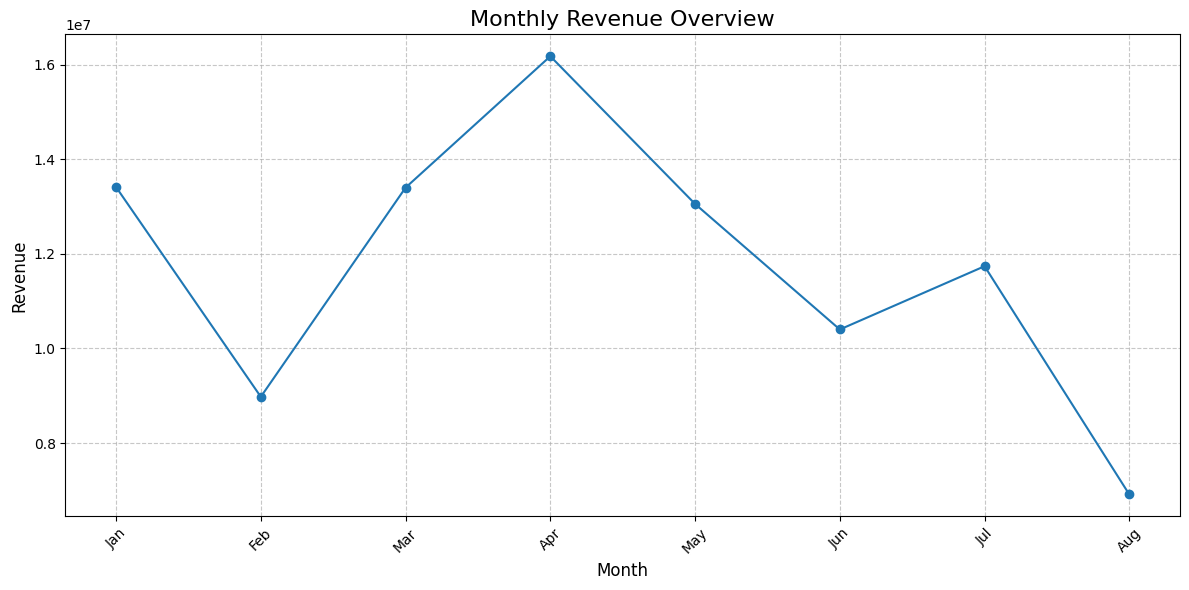


Month with highest revenue: Apr (Revenue: 16,175,912.00)
Month with lowest revenue: Aug (Revenue: 6,913,842.00)


In [ ]:
import matplotlib.pyplot as plt

# Extract the month from 'Order_Date'
df['Month'] = df['Order_Date'].dt.month

# Calculate total Revenue for each month
monthly_revenue = df.groupby('Month')['Revenue'].sum().reset_index()

# Convert month numbers to month names for better readability in the plot
monthly_revenue['Month_Name'] = monthly_revenue['Month'].apply(lambda x: pd.to_datetime(str(x), format='%m').strftime('%b'))

# Sort by month to ensure chronological order for plotting
monthly_revenue = monthly_revenue.sort_values(by='Month')

# Create the line chart
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue['Month_Name'], monthly_revenue['Revenue'], marker='o', linestyle='-')
plt.title('Monthly Revenue Overview', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotate x-axis labels if they overlap
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# Find months with highest and lowest revenue
highest_revenue_month = monthly_revenue.loc[monthly_revenue['Revenue'].idxmax()]
lowest_revenue_month = monthly_revenue.loc[monthly_revenue['Revenue'].idxmin()]

print(f"\nMonth with highest revenue: {highest_revenue_month['Month_Name']} (Revenue: {highest_revenue_month['Revenue']:,.2f})")
print(f"Month with lowest revenue: {lowest_revenue_month['Month_Name']} (Revenue: {lowest_revenue_month['Revenue']:,.2f})")

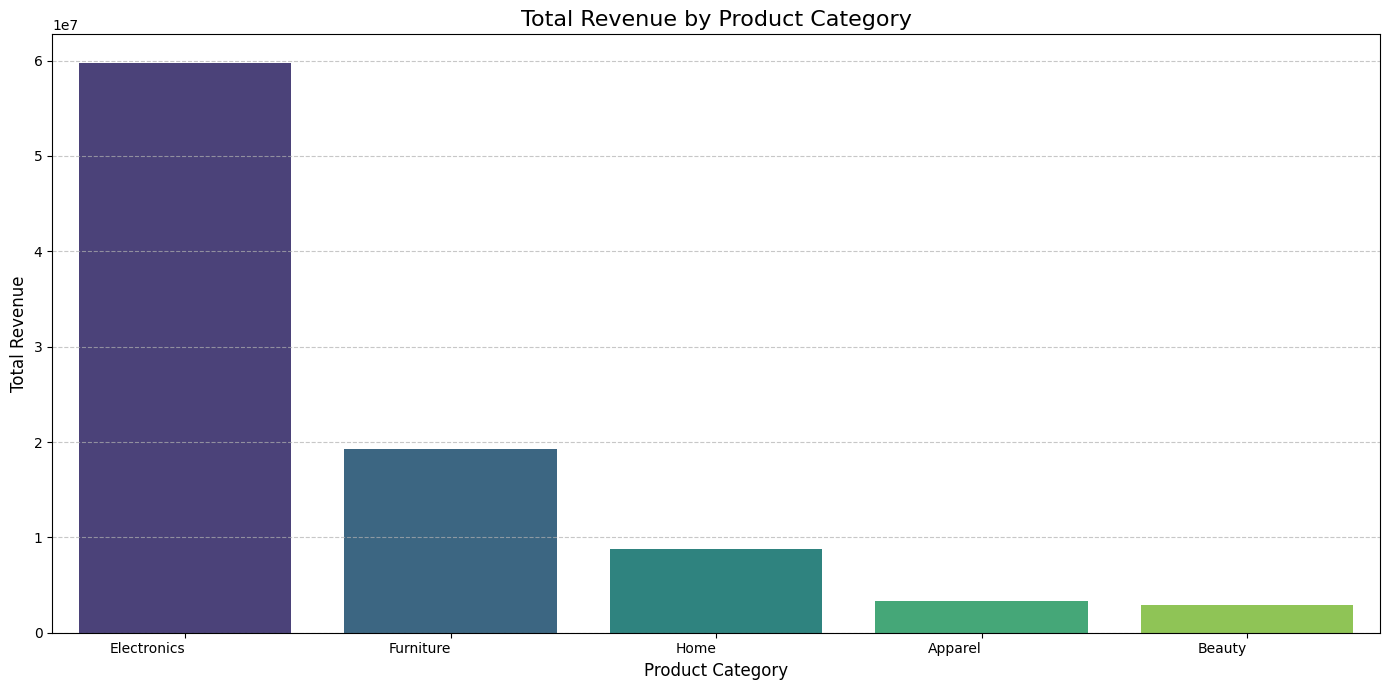


Category with highest revenue: Electronics (Revenue: 59,769,877.00)

Category with lowest revenue: Beauty (Revenue: 2,909,005.00)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total Revenue for each category
category_revenue = df.groupby('Category')['Revenue'].sum().reset_index()

# Sort categories from highest to lowest revenue
category_revenue = category_revenue.sort_values(by='Revenue', ascending=False)

# Create the bar chart
plt.figure(figsize=(14, 7))
sns.barplot(x='Category', y='Revenue',hue='Category', data=category_revenue, palette='viridis')
plt.title('Total Revenue by Product Category', fontsize=16)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=None, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# Identify category with highest revenue
highest_revenue_category = category_revenue.iloc[0]
lowest_revenue_category = category_revenue.iloc[-1]
print(f"\nCategory with highest revenue: {highest_revenue_category['Category']} (Revenue: {highest_revenue_category['Revenue']:,.2f})")
print(f"\nCategory with lowest revenue: {lowest_revenue_category['Category']} (Revenue: {lowest_revenue_category['Revenue']:,.2f})")


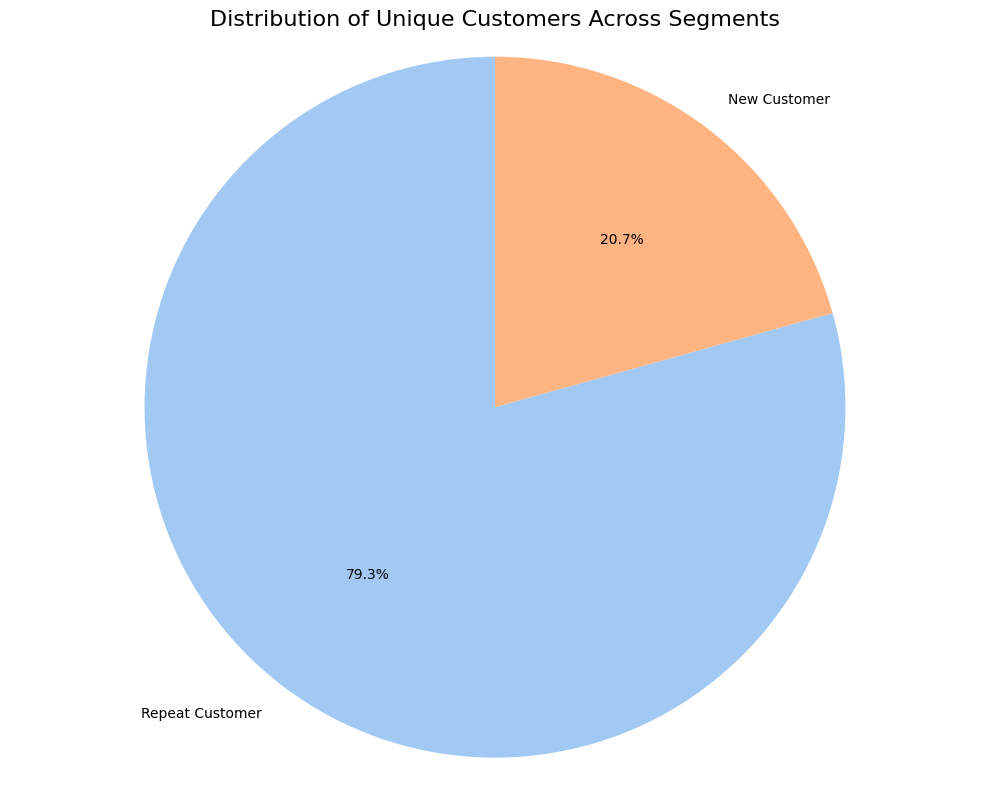

,Customer_Type,Unique_Customer_Count,Percentage
0,Repeat Customer,330,79.326923
1,New Customer,86,20.673077


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get unique Customer_ID and their Customer_Type
unique_customers = df[['Customer_ID', 'Customer_Type']].drop_duplicates()

# Count unique customers in each Customer_Segment
customer_segment_counts = unique_customers['Customer_Type'].value_counts().reset_index()
customer_segment_counts.columns = ['Customer_Type', 'Unique_Customer_Count']

# Calculate the percentage of customers in each segment
total_unique_customers = unique_customers['Customer_ID'].nunique()
customer_segment_counts['Percentage'] = (customer_segment_counts['Unique_Customer_Count'] / total_unique_customers) * 100

# Sort by count for better visualization (though less critical for pie charts)
customer_segment_counts = customer_segment_counts.sort_values(by='Unique_Customer_Count', ascending=False)

# Create a pie chart showing the customer segments
plt.figure(figsize=(10, 8))
plt.pie(customer_segment_counts['Unique_Customer_Count'],
        labels=customer_segment_counts['Customer_Type'],
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette('pastel', len(customer_segment_counts)))

# Add clear title
plt.title('Distribution of Unique Customers Across Segments', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

display(customer_segment_counts)

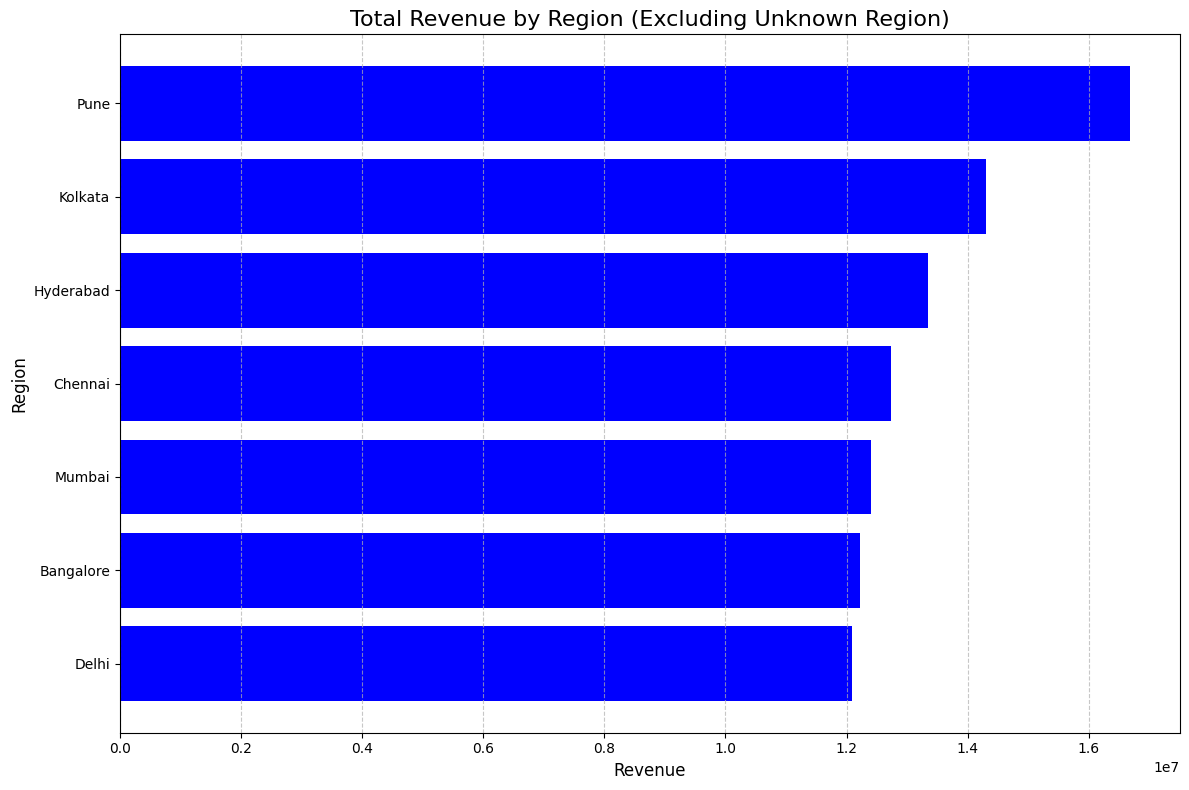

Region with highest revenue: Pune (Revenue: 16,674,776.00)
Region with lowest revenue: Delhi (Revenue: 12,083,236.00)


In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter out 'Unknown Region' before grouping
df_filtered = df[df['Region'] != 'Unknown Region'].copy()

# 1. Group the data by Region and 2. Calculate total Revenue for each region.
regional_revenue = df_filtered.groupby('Region')['Revenue'].sum().reset_index()

# 3. Sort regions from highest to lowest
regional_revenue = regional_revenue.sort_values(by='Revenue', ascending=False)

# Find the region with the highest revenue
highest_revenue_region = regional_revenue.iloc[0]
# Find the region with the lowest revenue
lowest_revenue_region = regional_revenue.iloc[-1]

# 4. Create a horizontal bar chart
plt.figure(figsize=(12, 8))
plt.barh(regional_revenue['Region'], regional_revenue['Revenue'], color='blue')

# 5. Add a clear title
plt.title('Total Revenue by Region (Excluding Unknown Region)', fontsize=16)

# 6. Labels the x-axis Revenue
plt.xlabel('Revenue', fontsize=12)

# 7. Labels the y-axis Region
plt.ylabel('Region', fontsize=12)

# Invert y-axis to have the highest revenue at the top
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Region with highest revenue: {highest_revenue_region['Region']} (Revenue: {highest_revenue_region['Revenue']:,.2f})")
print(f"Region with lowest revenue: {lowest_revenue_region['Region']} (Revenue: {lowest_revenue_region['Revenue']:,.2f})")

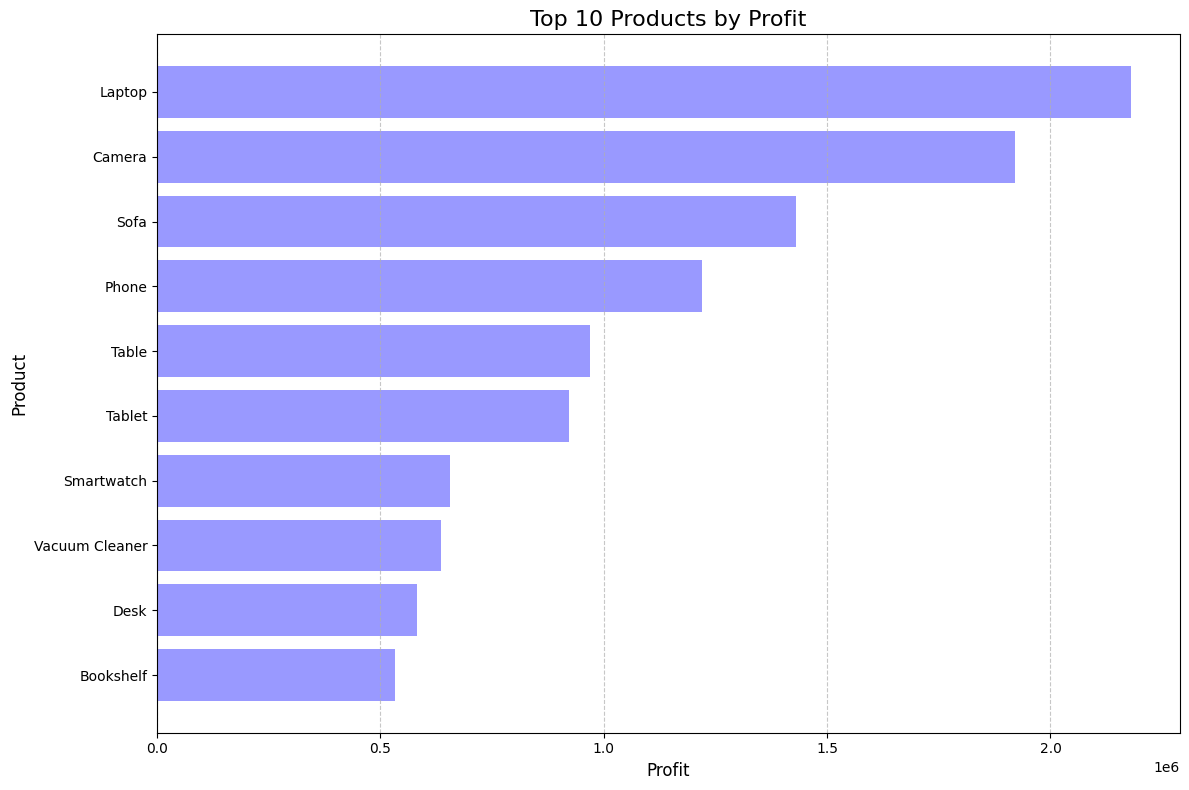

Top 10 Products by Profit:


,Product,Profit
10,Laptop,2180953.0
2,Camera,1921456.0
18,Sofa,1431096.0
14,Phone,1219618.0
21,Table,969406.0
22,Tablet,922905.0
17,Smartwatch,656570.0
24,Vacuum Cleaner,635564.0
5,Desk,581012.0
1,Bookshelf,532463.0


In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Group the data by Product and 2. Calculate total Profit for each product.
product_profit = df.groupby('Product')['Profit'].sum().reset_index()

# 3. Sort products from highest to lowest profit
product_profit = product_profit.sort_values(by='Profit', ascending=False)

# 4. Select the top 10 products
top_10_products = product_profit.head(10)

# 5. Create a horizontal bar chart
plt.figure(figsize=(12, 8))
plt.barh(top_10_products['Product'], top_10_products['Profit'], color='blue',alpha=0.4)

# 6. Add a clear title
plt.title('Top 10 Products by Profit', fontsize=16)

# 7. Labels the x-axis Profit
plt.xlabel('Profit', fontsize=12)

# 8. Labels the y-axis Product
plt.ylabel('Product', fontsize=12)

# Invert y-axis to have the highest profit at the top
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top 10 Products by Profit:")
display(top_10_products)